# BNO085 采集端诊断（Acquisition-side Diagnostic）

目标：在做噪声建模之前，先把**采集端（firmware / 驱动 / 时间戳 / 量程）**的问题摸清楚。

本 notebook 不分析噪声，只回答："采集到的这份 CSV 本身可不可信？"

**数据源**：用户已经把固件产出的二进制文件（`fast_data.bin`）转成三个独立的 CSV：
`gyroscope.csv`、`accelerometer.csv`、`magnetometer.csv`。本 notebook 直接读这三个 CSV。

检查项：
1. 时间戳：单调、均匀、丢包
2. 量程：超出 BNO085 物理满量程
3. 位边界聚集：±127, ±2047, ±32767 这类字节宽度 bug
4. LSB 量化步一致性：驱动是否在两套 scale 间切换
5. Stuck / repeated 采样：SPI/SHTP 读失败返回缓存
6. 重复行 / NaN / 全零
7. DC 阶跃跳变
8. 三传感器时间同步

每项输出：数值 + PASS/WARN/FAIL + 图 + 可执行的修复建议。

换 run 只需改 `DATA_ROOT`，Run All 即可。

In [1]:
import os, sys, math, json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 11, 'axes.labelsize': 10, 'lines.linewidth': 0.8,
})
COLORS = {'x': '#E74C3C', 'y': '#2ECC71', 'z': '#3498DB'}


RUN_ID     = "008"
DATA_ROOT  = f"/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_{RUN_ID}"


BNO085_FS = {
    'gyro':  34.9066,   # +/- 2000 dps
    'accel': 156.9060,  # +/- 16 g
    'mag':   1300.0,    # +/- 1300 uT
}
BNO085_LSB = {
    'gyro':  1.0 / 512.0,
    'accel': 1.0 / 256.0,
    'mag':   1.0 / 16.0,
}
# Nominal report rates actually configured by the firmware:
# - vTaskFast loops at 1 ms; all three IMU reports are enabled with
#   .enable(1000UL) -> 1000 us period = 1000 Hz requested.
# - BNO085 uncal magnetometer caps at ~100 Hz in hardware, so mag's effective
#   rate is ~100 Hz even though the firmware asks for 1000 Hz.
NOMINAL_HZ = {'gyro': 1000.0, 'accel': 1000.0, 'mag': 100.0}


IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except Exception as e:
        print(f"[warn] drive mount skipped: {e}")


REPORT = {'run': RUN_ID, 'checks': []}

def record(name, sensor, status, detail, **kwargs):
    """status in {'PASS','WARN','FAIL'}; detail = human-readable one-liner."""
    REPORT['checks'].append({
        'check': name, 'sensor': sensor, 'status': status, 'detail': detail, **kwargs
    })
    tag = {'PASS': '\u2713 PASS', 'WARN': '! WARN', 'FAIL': 'X FAIL'}[status]
    print(f"  [{tag}] {sensor:<5}  {name:<32}  {detail}")


def load_sensor(path, name):
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    tcol = next((cols[k] for k in cols if 'time' in k or 'ts' in k or k == 't'), df.columns[0])
    xyz  = []
    for k in ['x','y','z']:
        cand = [c for c in df.columns if c.lower() == k or c.lower().endswith('_'+k)]
        if cand:
            xyz.append(cand[0])
    if len(xyz) < 3:
        xyz = [c for c in df.columns if c != tcol][:3]
    df = df[[tcol] + xyz].copy()
    df.columns = ['t_ms', 'x', 'y', 'z']
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['time_s'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0
    return df

print("=" * 70)
print(f"  BNO085 Acquisition-side Diagnostic  —  RUN_{RUN_ID}")
print("=" * 70)
print(f"  DATA_ROOT = {DATA_ROOT}")

SENSORS = {}
for name, fn in [('gyro','gyroscope.csv'), ('accel','accelerometer.csv'), ('mag','magnetometer.csv')]:
    path = os.path.join(DATA_ROOT, fn)
    if not os.path.exists(path):
        print(f"  [skip] {name}: file not found at {path}")
        continue
    df = load_sensor(path, name)
    SENSORS[name] = df
    print(f"  loaded {name:<5}  rows={len(df):>10,}  "
          f"duration={df['time_s'].iloc[-1]:.1f}s  "
          f"cols={list(df.columns)}")
print()

Mounted at /content/drive
  BNO085 Acquisition-side Diagnostic  —  RUN_008
  DATA_ROOT = /content/drive/MyDrive/capstone_data/UNIT_0001_RUN_008
  loaded gyro   rows= 5,396,259  duration=54000.0s  cols=['t_ms', 'x', 'y', 'z', 'time_s']
  loaded accel  rows=13,275,250  duration=54000.0s  cols=['t_ms', 'x', 'y', 'z', 'time_s']
  loaded mag    rows= 5,382,776  duration=54000.0s  cols=['t_ms', 'x', 'y', 'z', 'time_s']



## Check 1 — 时间戳诊断

问题：时间戳是不是单调、均匀、没丢包？
- **单调性**：`dt <= 0` 的数量（如果出现就是驱动写入顺序或多线程 race）
- **重复时间戳**：dt = 0（驱动同一刻写了两行）
- **dt 直方图**：理想应该是一个尖峰；如果是双峰 / 多峰说明调度抖动严重
- **Dropout（大间隙）**：dt > 5 × median → 通讯栈 stall 或 FIFO 溢出
- **实测采样率 vs 标称**：应接近 100 / 200 Hz

[1/8] Timestamp diagnostics
----------------------------------------------------------------------
  [✓ PASS] gyro   timestamp monotonic               strictly increasing (5,396,258 intervals)
  [X FAIL] gyro   sampling rate vs nominal          100.00 Hz vs nominal 1000.0 Hz (90.0% off)
  [! WARN] gyro   timestamp jitter (CV)             CV=11.7%  (median=10.00ms, p99=13.0ms, max=279ms)
  [! WARN] gyro   packet dropouts                   80 gaps >5x median, totalling 10.23s (max 0.28s)
  [✓ PASS] accel  timestamp monotonic               strictly increasing (13,275,249 intervals)
  [X FAIL] accel  sampling rate vs nominal          333.33 Hz vs nominal 1000.0 Hz (66.7% off)
  [X FAIL] accel  timestamp jitter (CV)             CV=55.1% — heavy scheduling noise
  [! WARN] accel  packet dropouts                   6055 gaps >5x median, totalling 111.59s (max 0.27s)
  [✓ PASS] mag    timestamp monotonic               strictly increasing (5,382,775 intervals)
  [✓ PASS] mag    sampling rate vs 

/tmp/ipykernel_3203/76445792.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_3203/76445792.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"diag_{RUN_ID}_01_timestamp.png", bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


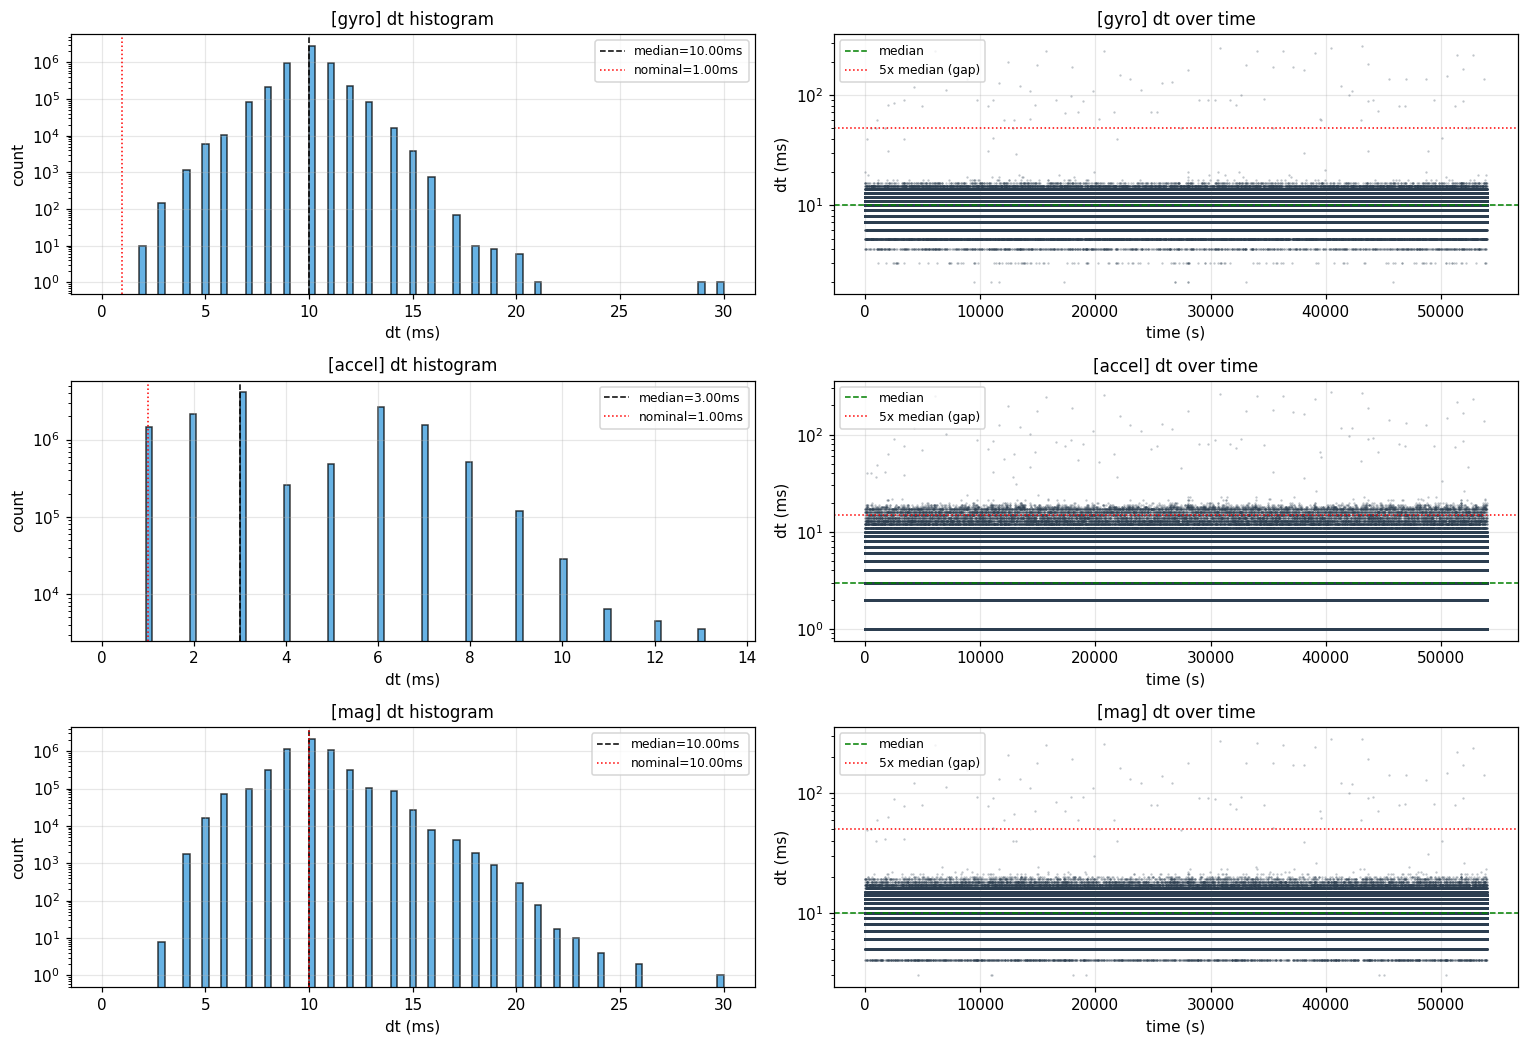

In [2]:
print("[1/8] Timestamp diagnostics")
print("-" * 70)

fig, axes_p = plt.subplots(len(SENSORS), 2, figsize=(14, 3.2 * len(SENSORS)))
if len(SENSORS) == 1:
    axes_p = axes_p.reshape(1, -1)

for i, (name, df) in enumerate(SENSORS.items()):
    dt = df['t_ms'].diff().dropna().values
    n_total = len(dt)

    n_nonpos    = int((dt <= 0).sum())
    n_zero      = int((dt == 0).sum())
    n_negative  = int((dt < 0).sum())
    dt_positive = dt[dt > 0]
    if len(dt_positive) == 0:
        print(f"  [{name}] no positive dt — file broken?")
        continue

    dt_median = float(np.median(dt_positive))
    dt_mean   = float(dt_positive.mean())
    dt_std    = float(dt_positive.std())
    dt_p99    = float(np.percentile(dt_positive, 99))
    dt_max    = float(dt_positive.max())
    fs_est    = 1000.0 / dt_median
    fs_nom    = NOMINAL_HZ.get(name, fs_est)

    gap_thresh = 5 * dt_median
    n_gaps = int((dt > gap_thresh).sum())
    total_gap_ms = float(dt[dt > gap_thresh].sum())
    cv = dt_std / dt_mean if dt_mean > 0 else np.nan

    if n_negative > 0:
        record('timestamp monotonic', name, 'FAIL',
               f"{n_negative} backward jumps (dt<0)", count=n_negative)
    elif n_zero > 0:
        record('timestamp monotonic', name, 'WARN',
               f"{n_zero} duplicate-time rows (dt=0)", count=n_zero)
    else:
        record('timestamp monotonic', name, 'PASS',
               f"strictly increasing ({n_total:,} intervals)")

    rel = abs(fs_est - fs_nom) / fs_nom if fs_nom else 0
    if rel < 0.02:
        record('sampling rate vs nominal', name, 'PASS',
               f"{fs_est:.2f} Hz  (nominal {fs_nom} Hz, diff {rel*100:.2f}%)")
    elif rel < 0.10:
        record('sampling rate vs nominal', name, 'WARN',
               f"{fs_est:.2f} Hz vs nominal {fs_nom} Hz ({rel*100:.1f}% off)")
    else:
        record('sampling rate vs nominal', name, 'FAIL',
               f"{fs_est:.2f} Hz vs nominal {fs_nom} Hz ({rel*100:.1f}% off)")

    if cv < 0.05:
        record('timestamp jitter (CV)', name, 'PASS',
               f"CV={cv*100:.2f}%  (median={dt_median:.2f}ms, p99={dt_p99:.1f}ms)")
    elif cv < 0.30:
        record('timestamp jitter (CV)', name, 'WARN',
               f"CV={cv*100:.1f}%  (median={dt_median:.2f}ms, p99={dt_p99:.1f}ms, max={dt_max:.0f}ms)")
    else:
        record('timestamp jitter (CV)', name, 'FAIL',
               f"CV={cv*100:.1f}% — heavy scheduling noise")

    gap_pct = n_gaps / n_total * 100
    total_gap_s = total_gap_ms / 1000.0
    if n_gaps == 0:
        record('packet dropouts', name, 'PASS', "no gap > 5x median dt")
    elif gap_pct < 0.01 and total_gap_s < 1:
        record('packet dropouts', name, 'PASS',
               f"{n_gaps} tiny gaps ({total_gap_s:.2f}s total)")
    elif gap_pct < 0.1:
        record('packet dropouts', name, 'WARN',
               f"{n_gaps} gaps >5x median, totalling {total_gap_s:.2f}s (max {dt_max/1000:.2f}s)")
    else:
        record('packet dropouts', name, 'FAIL',
               f"{n_gaps} gaps ({gap_pct:.2f}%) totalling {total_gap_s:.2f}s")

    ax_h = axes_p[i, 0]
    bins = np.linspace(0, max(dt_p99 * 1.5, dt_median * 3), 100)
    ax_h.hist(dt_positive, bins=bins, color='#3498DB', alpha=0.75, edgecolor='k', lw=0.3)
    ax_h.axvline(dt_median, color='k', ls='--', lw=1, label=f'median={dt_median:.2f}ms')
    ax_h.axvline(1000.0 / fs_nom, color='r', ls=':', lw=1, label=f'nominal={1000.0/fs_nom:.2f}ms')
    ax_h.set_xlabel('dt (ms)')
    ax_h.set_ylabel('count')
    ax_h.set_yscale('log')
    ax_h.set_title(f'[{name}] dt histogram')
    ax_h.legend(fontsize=8)

    ax_t = axes_p[i, 1]
    t_mid = df['time_s'].values[1:]
    ax_t.plot(t_mid, dt, '.', ms=1, color='#2C3E50', alpha=0.3, rasterized=True)
    ax_t.axhline(dt_median, color='g', ls='--', lw=1, label=f'median')
    ax_t.axhline(gap_thresh, color='r', ls=':', lw=1, label='5x median (gap)')
    ax_t.set_xlabel('time (s)')
    ax_t.set_ylabel('dt (ms)')
    ax_t.set_yscale('log')
    ax_t.set_title(f'[{name}] dt over time')
    ax_t.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"diag_{RUN_ID}_01_timestamp.png", bbox_inches='tight')
plt.show()
print()

## Check 2 — 物理量程（FS）合规

BNO085 出厂默认量程：
- Gyro  : ±2000 dps = ±34.9 rad/s
- Accel : ±16 g   = ±156.9 m/s²
- Mag   : ±1300 µT

**超过这个范围 = 驱动在把寄存器字节错误地解读成物理量**（常见原因：byte order、没乘 scale、读到了错的寄存器）。
物理上不可能出现，所以出现一次就是 firmware bug。

[2/8] Physical full-scale compliance
----------------------------------------------------------------------
  [✓ PASS] gyro   full-scale compliance             over-FS samples (|v|>34.9066): x=0, y=0, z=0 (any-axis 0, 0.0000%)
  [✓ PASS] accel  full-scale compliance             over-FS samples (|v|>156.906): x=0, y=0, z=0 (any-axis 0, 0.0000%)
  [✓ PASS] mag    full-scale compliance             over-FS samples (|v|>1300): x=0, y=0, z=0 (any-axis 0, 0.0000%)


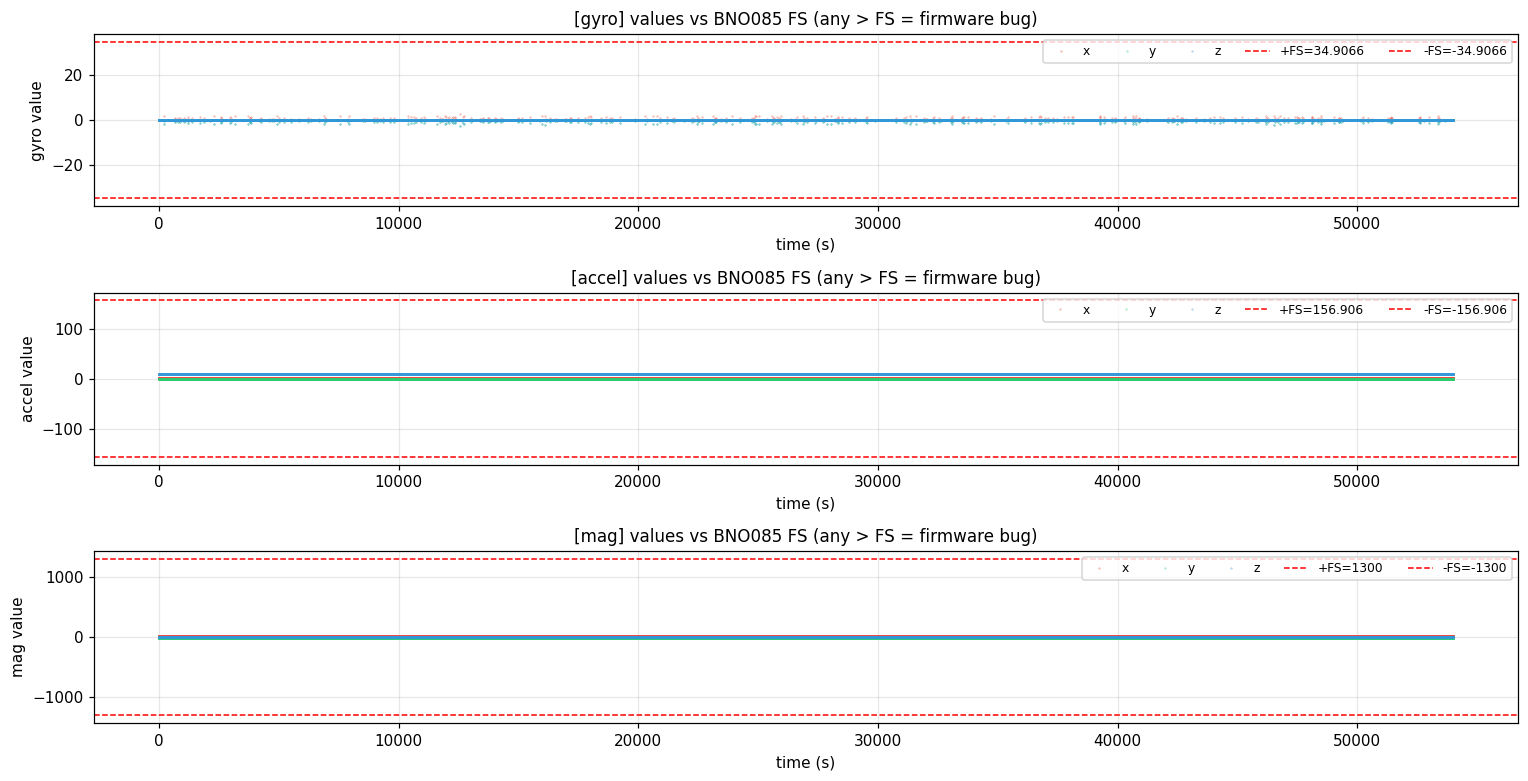

In [3]:
print("[2/8] Physical full-scale compliance")
print("-" * 70)

fig, axes_p = plt.subplots(len(SENSORS), 1, figsize=(14, 2.4 * len(SENSORS)))
if len(SENSORS) == 1:
    axes_p = [axes_p]

for i, (name, df) in enumerate(SENSORS.items()):
    fs = BNO085_FS[name]
    n_total = len(df)
    any_over = np.zeros(n_total, dtype=bool)
    per_axis = {}
    for ax in ['x','y','z']:
        mask = df[ax].abs() > fs
        per_axis[ax] = int(mask.sum())
        any_over |= mask.values
    n_over = int(any_over.sum())
    pct    = n_over / n_total * 100

    detail = (f"over-FS samples (|v|>{fs:g}): "
              f"x={per_axis['x']}, y={per_axis['y']}, z={per_axis['z']} "
              f"(any-axis {n_over}, {pct:.4f}%)")
    if n_over == 0:
        record('full-scale compliance', name, 'PASS', detail)
    elif pct < 0.01:
        record('full-scale compliance', name, 'WARN', detail)
    else:
        record('full-scale compliance', name, 'FAIL', detail)

    ax_p = axes_p[i]
    for axn in ['x','y','z']:
        ax_p.plot(df['time_s'].values[::max(1,len(df)//50000)],
                  df[axn].values[::max(1,len(df)//50000)],
                  '.', ms=0.8, color=COLORS[axn], alpha=0.5, label=axn, rasterized=True)
    ax_p.axhline( fs, color='r', ls='--', lw=1, label=f'+FS={fs:g}')
    ax_p.axhline(-fs, color='r', ls='--', lw=1, label=f'-FS={-fs:g}')
    ax_p.set_xlabel('time (s)')
    ax_p.set_ylabel(f'{name} value')
    ax_p.set_title(f'[{name}] values vs BNO085 FS (any > FS = firmware bug)')
    ax_p.legend(fontsize=8, ncol=5)
    if n_over > 0:
        ax_p.set_yscale('symlog', linthresh=fs * 0.1)

plt.tight_layout()
plt.savefig(f"diag_{RUN_ID}_02_fullscale.png", bbox_inches='tight')
plt.show()
print()

## Check 3 — 可疑整数边界聚集（字节宽度 bug）

原始寄存器是有符号整数。用 LSB 反推回"原始整数"后，如果大量读数卡在：

| 边界值 | 含义 |
|---|---|
| ±127 / ±128 | int8 饱和（读了 8-bit 寄存器但当作 16-bit）|
| ±2047 / ±2048 | 12-bit 饱和（SHTP 或 raw 字段）|
| ±32767 / ±32768 | int16 饱和（正常传感器满量程，但你不旋转不应该到）|

→ 基本可以判定为**字节宽度 / 符号位错误**。

[3/8] Suspicious integer-boundary clustering (byte-width bug)
----------------------------------------------------------------------
  [✓ PASS] gyro   integer-boundary clustering       no samples near int8/12/16 saturation boundaries
  [X FAIL] accel  integer-boundary clustering       |127|:2126057, |128|:2126057  (worst 127: 2126057 samples, 5.3384%)
  [✓ PASS] mag    integer-boundary clustering       no samples near int8/12/16 saturation boundaries


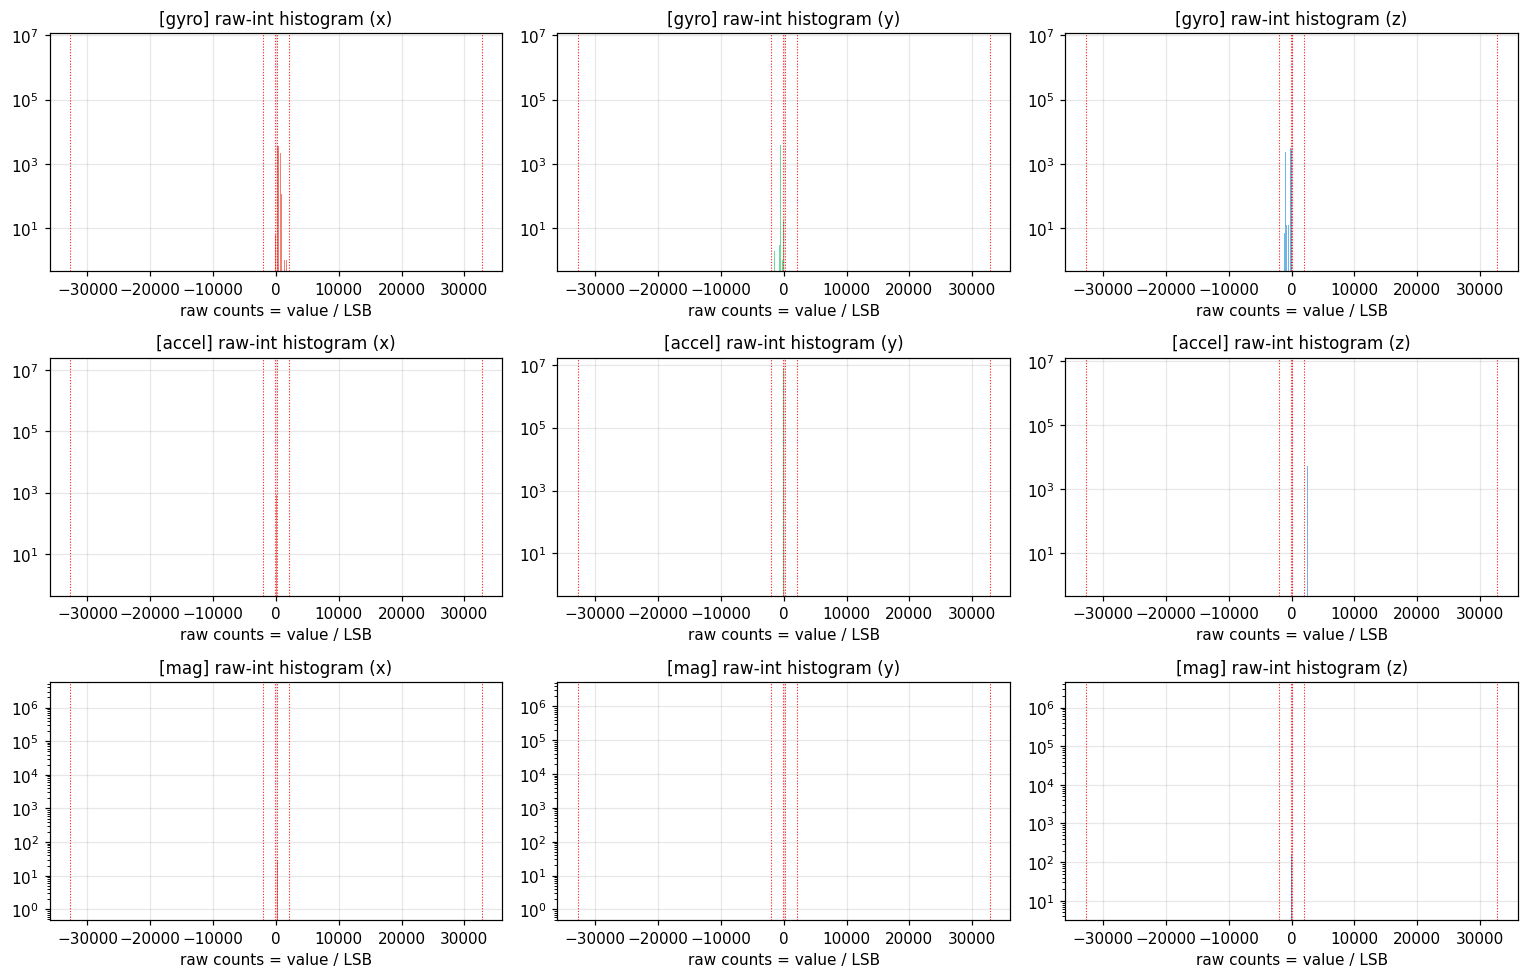

In [4]:
print("[3/8] Suspicious integer-boundary clustering (byte-width bug)")
print("-" * 70)

SUSPICIOUS = [127, 128, 2047, 2048, 32767, 32768]
TOL = 1.5

for name, df in SENSORS.items():
    lsb = BNO085_LSB[name]
    raw_x = (df['x'] / lsb).values
    raw_y = (df['y'] / lsb).values
    raw_z = (df['z'] / lsb).values

    hits = {}
    for b in SUSPICIOUS:
        hit = 0
        for arr in [raw_x, raw_y, raw_z]:
            hit += int(((np.abs(np.abs(arr) - b)) < TOL).sum())
        hits[b] = hit

    active = {b: c for b, c in hits.items() if c > 0}
    n_total = len(df) * 3

    if not active:
        record('integer-boundary clustering', name, 'PASS',
               "no samples near int8/12/16 saturation boundaries")
    else:
        worst_b = max(active, key=active.get)
        worst_c = active[worst_b]
        pct = worst_c / n_total * 100
        txt = ", ".join(f"|{b}|:{c}" for b,c in active.items())
        if pct < 0.001:
            level = 'WARN'
        elif pct < 0.05:
            level = 'WARN'
        else:
            level = 'FAIL'
        record('integer-boundary clustering', name, level,
               f"{txt}  (worst {worst_b}: {worst_c} samples, {pct:.4f}%)")


fig, axes_p = plt.subplots(len(SENSORS), 3, figsize=(14, 3.0 * len(SENSORS)))
if len(SENSORS) == 1:
    axes_p = axes_p.reshape(1, -1)
for i, (name, df) in enumerate(SENSORS.items()):
    lsb = BNO085_LSB[name]
    for j, axn in enumerate(['x','y','z']):
        raw = (df[axn] / lsb).values
        r_abs_max = np.abs(raw).max()
        upper = max(r_abs_max * 1.05, 2500)
        bins = np.linspace(-upper, upper, 400)
        axes_p[i,j].hist(raw, bins=bins, color=COLORS[axn], alpha=0.7)
        axes_p[i,j].set_yscale('log')
        for b in SUSPICIOUS:
            axes_p[i,j].axvline( b, color='r', ls=':', lw=0.7, alpha=0.6)
            axes_p[i,j].axvline(-b, color='r', ls=':', lw=0.7, alpha=0.6)
        axes_p[i,j].set_title(f'[{name}] raw-int histogram ({axn})')
        axes_p[i,j].set_xlabel('raw counts = value / LSB')
plt.tight_layout()
plt.savefig(f"diag_{RUN_ID}_03_boundary.png", bbox_inches='tight')
plt.show()
print()

## Check 4 — LSB 量化步一致性

BNO085 每种传感器只有一个 scale factor。真实数据应该是 LSB 的**整数倍**：
- gyro  LSB ≈ 1/512 rad/s
- accel LSB ≈ 1/256 m/s²
- mag   LSB ≈ 1/16 µT

检查：
1. `residual = value mod LSB` 应≈ 0（容忍浮点转换误差）
2. 相邻不同值之间的最小步长，应与 LSB 一致
3. 如果出现两种以上的"步长"，说明驱动在不同时间使用了不同 scale

In [5]:
print("[4/8] LSB quantization consistency")
print("-" * 70)

for name, df in SENSORS.items():
    lsb = BNO085_LSB[name]
    reports = []
    multi_step = []
    for axn in ['x','y','z']:
        v = df[axn].dropna().values
        raw = v / lsb
        frac = raw - np.round(raw)
        max_frac = float(np.abs(frac).max())
        mean_frac = float(np.abs(frac).mean())
        reports.append((axn, max_frac, mean_frac))

        diffs = np.diff(np.unique(v))
        diffs = diffs[diffs > 0]
        if len(diffs) == 0:
            continue
        min_step = float(diffs.min())
        ratio = min_step / lsb
        if abs(ratio - round(ratio)) > 0.05 or ratio < 0.5:
            multi_step.append((axn, min_step, lsb, ratio))

    max_frac_any = max(r[1] for r in reports)
    if max_frac_any < 0.05:
        record('LSB alignment', name, 'PASS',
               f"max |value/LSB - round| = {max_frac_any:.3f} (ideal 0)")
    elif max_frac_any < 0.25:
        record('LSB alignment', name, 'WARN',
               f"max fractional residual = {max_frac_any:.3f} — LSB may be off")
    else:
        record('LSB alignment', name, 'FAIL',
               f"fractional residual = {max_frac_any:.3f} — scale factor WRONG")

    if not multi_step:
        record('single-scale driver', name, 'PASS', "min step consistent with declared LSB")
    else:
        txt = "; ".join(f"{ax}: min_step={ms:.5g} vs LSB {l:.5g} (r={r:.2f})"
                       for ax,ms,l,r in multi_step)
        record('single-scale driver', name, 'WARN',
               f"unexpected step sizes — {txt}")

print()

[4/8] LSB quantization consistency
----------------------------------------------------------------------
  [✓ PASS] gyro   LSB alignment                     max |value/LSB - round| = 0.000 (ideal 0)
  [✓ PASS] gyro   single-scale driver               min step consistent with declared LSB
  [✓ PASS] accel  LSB alignment                     max |value/LSB - round| = 0.000 (ideal 0)
  [✓ PASS] accel  single-scale driver               min step consistent with declared LSB
  [✓ PASS] mag    LSB alignment                     max |value/LSB - round| = 0.000 (ideal 0)
  [✓ PASS] mag    single-scale driver               min step consistent with declared LSB



## Check 5 — Stuck / repeated 采样

I²C/SHTP 读失败时，驱动常常返回上一次的缓存值 → 连续多个采样完全相同。真实传感器在噪声下**几乎不可能连续相同**（量化步 + 热噪声几乎总会抖出去）。

指标：最长"完全相同连续段"的长度（per axis 全匹配）。预期 ≤ 2。

[5/8] Stuck / repeated samples (cached-read bug)
----------------------------------------------------------------------
  [X FAIL] gyro   stuck-value detection             longest identical-triplet run = 7; n_runs(>=3) = 20158 (0.3736%)
  [X FAIL] accel  stuck-value detection             longest identical-triplet run = 9; n_runs(>=3) = 68634 (0.5170%)
  [X FAIL] mag    stuck-value detection             longest identical-triplet run = 4; n_runs(>=3) = 632 (0.0117%)


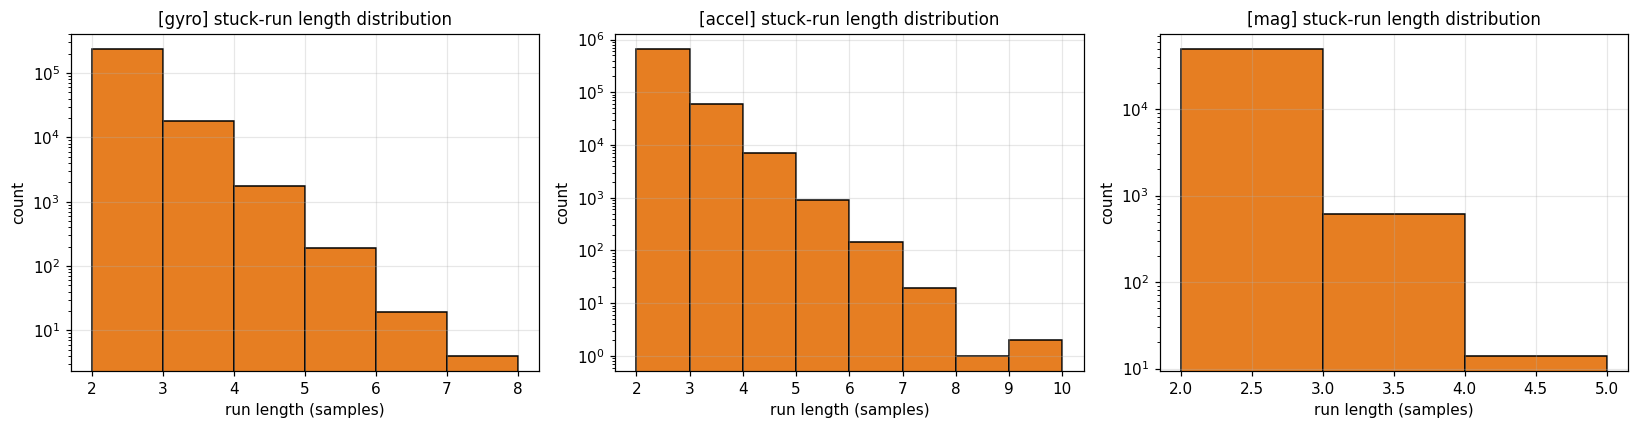

In [6]:
print("[5/8] Stuck / repeated samples (cached-read bug)")
print("-" * 70)

def longest_run_of_equal_triples(arr_x, arr_y, arr_z):
    """Return (max_run, num_runs_ge_3)."""
    eq = (arr_x[1:] == arr_x[:-1]) & (arr_y[1:] == arr_y[:-1]) & (arr_z[1:] == arr_z[:-1])
    if not eq.any():
        return 1, 0
    max_run = 1
    cur = 1
    num_ge3 = 0
    for e in eq:
        if e:
            cur += 1
            if cur > max_run:
                max_run = cur
        else:
            if cur >= 3:
                num_ge3 += 1
            cur = 1
    if cur >= 3:
        num_ge3 += 1
    return int(max_run), int(num_ge3)


fig, axes_p = plt.subplots(1, len(SENSORS), figsize=(5 * len(SENSORS), 4))
if len(SENSORS) == 1:
    axes_p = [axes_p]

for i, (name, df) in enumerate(SENSORS.items()):
    x = df['x'].values; y = df['y'].values; z = df['z'].values
    max_run, n_runs_ge3 = longest_run_of_equal_triples(x, y, z)
    run_pct = n_runs_ge3 / len(df) * 100

    detail = f"longest identical-triplet run = {max_run}; n_runs(>=3) = {n_runs_ge3} ({run_pct:.4f}%)"
    if max_run <= 2:
        record('stuck-value detection', name, 'PASS', detail)
    elif max_run <= 10 and run_pct < 0.01:
        record('stuck-value detection', name, 'WARN', detail)
    else:
        record('stuck-value detection', name, 'FAIL', detail)

    eq = (x[1:] == x[:-1]) & (y[1:] == y[:-1]) & (z[1:] == z[:-1])
    runs = []
    cur = 1
    for e in eq:
        if e: cur += 1
        else:
            if cur >= 2: runs.append(cur)
            cur = 1
    if cur >= 2: runs.append(cur)
    if runs:
        bins = np.arange(2, max(runs) + 2)
        axes_p[i].hist(runs, bins=bins, color='#E67E22', edgecolor='k', lw=0.3)
        axes_p[i].set_yscale('log')
    axes_p[i].set_title(f'[{name}] stuck-run length distribution')
    axes_p[i].set_xlabel('run length (samples)')
    axes_p[i].set_ylabel('count')

plt.tight_layout()
plt.savefig(f"diag_{RUN_ID}_05_stuck.png", bbox_inches='tight')
plt.show()
print()

## Check 6 — 重复行 / NaN / 全零包

In [7]:
print("[6/8] Duplicates / NaN / all-zero rows")
print("-" * 70)

for name, df in SENSORS.items():
    n_total = len(df)
    n_dup_full  = int(df.duplicated().sum())
    n_dup_t     = int(df['t_ms'].duplicated().sum())
    n_nan_any   = int(df[['x','y','z']].isna().any(axis=1).sum())
    n_all_zero  = int(((df['x'] == 0) & (df['y'] == 0) & (df['z'] == 0)).sum())

    if n_nan_any == 0:
        record('NaN / missing', name, 'PASS', f"no NaN in x/y/z")
    elif n_nan_any / n_total < 1e-4:
        record('NaN / missing', name, 'WARN', f"{n_nan_any} NaN samples ({n_nan_any/n_total*100:.4f}%)")
    else:
        record('NaN / missing', name, 'FAIL', f"{n_nan_any} NaN samples ({n_nan_any/n_total*100:.3f}%)")

    if n_dup_full == 0 and n_dup_t == 0:
        record('duplicate rows', name, 'PASS', "no duplicated rows or timestamps")
    elif n_dup_full > 0:
        record('duplicate rows', name, 'FAIL',
               f"{n_dup_full} fully duplicated rows, {n_dup_t} dup timestamps")
    else:
        record('duplicate rows', name, 'WARN',
               f"{n_dup_t} duplicated timestamps (values differ)")

    # Firmware gates each sample with has_new_data() before pushing to the
    # queue (see drivers/driver_{gyro,accel,mag}.cpp), so an all-zero row
    # should essentially never happen for any IMU axis. Use a strict budget
    # across all three sensors.
    expected_zero_rate = 0.001
    zero_rate = n_all_zero / n_total
    if zero_rate < expected_zero_rate:
        record('all-zero packets', name, 'PASS',
               f"{n_all_zero} all-zero rows ({zero_rate*100:.3f}%)")
    elif zero_rate < expected_zero_rate * 5:
        record('all-zero packets', name, 'WARN',
               f"{n_all_zero} all-zero rows ({zero_rate*100:.2f}%) — possibly I/O failure fill")
    else:
        record('all-zero packets', name, 'FAIL',
               f"{n_all_zero} all-zero rows ({zero_rate*100:.2f}%)")

print()

[6/8] Duplicates / NaN / all-zero rows
----------------------------------------------------------------------
  [✓ PASS] gyro   NaN / missing                     no NaN in x/y/z
  [✓ PASS] gyro   duplicate rows                    no duplicated rows or timestamps
  [✓ PASS] gyro   all-zero packets                  79 all-zero rows (0.001%)
  [✓ PASS] accel  NaN / missing                     no NaN in x/y/z
  [✓ PASS] accel  duplicate rows                    no duplicated rows or timestamps
  [✓ PASS] accel  all-zero packets                  0 all-zero rows (0.000%)
  [✓ PASS] mag    NaN / missing                     no NaN in x/y/z
  [✓ PASS] mag    duplicate rows                    no duplicated rows or timestamps
  [✓ PASS] mag    all-zero packets                  0 all-zero rows (0.000%)



## Check 7 — DC 阶跃跳变（driver 复位 / scale 切换）

静态下，长期 median 应当接近常数。如果出现 bias 的**阶跃跳变**（不是缓慢漂移），典型原因是驱动被重启、BNO085 做了 calibration restart，或者 scale 切换。

用"滑动 median 差分"检测：如果相邻窗口 median 差 > 5σ 就报告。

[7/8] DC step-change detection (driver reset / scale switch)
----------------------------------------------------------------------
  [X FAIL] gyro   DC step-change                    12 step-changes: x@11257s dm=+0.001953; x@11317s dm=-0.001953; x@11467s dm=+0.001953 ...
  [✓ PASS] accel  DC step-change                    no median jump > 5·robust_sigma


/tmp/ipykernel_3203/3679320685.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes_p[i].legend(fontsize=8)


  [✓ PASS] mag    DC step-change                    no median jump > 5·robust_sigma


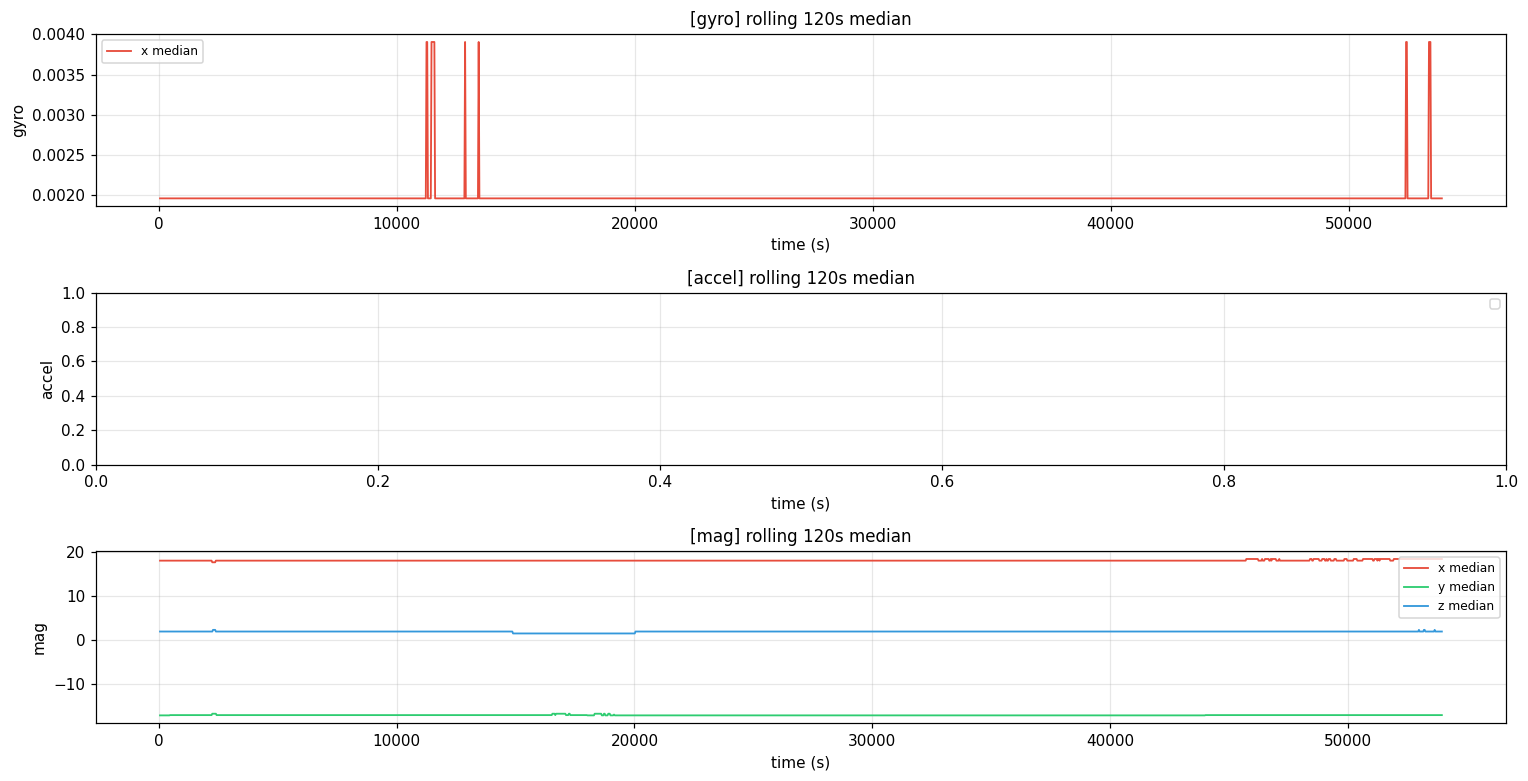

In [8]:
print("[7/8] DC step-change detection (driver reset / scale switch)")
print("-" * 70)

fig, axes_p = plt.subplots(len(SENSORS), 1, figsize=(14, 2.4 * len(SENSORS)))
if len(SENSORS) == 1:
    axes_p = [axes_p]

for i, (name, df) in enumerate(SENSORS.items()):
    fs = BNO085_FS[name]
    n = len(df)

    WIN_SEC = 120.0
    fs_est = 1000.0 / max(float(df['t_ms'].diff().median()), 0.1)
    win = max(1000, int(WIN_SEC * fs_est))

    n_steps_total = 0
    step_details = []
    for axn in ['x','y','z']:
        v = df[axn].clip(-fs, fs).values
        if len(v) < 2 * win:
            continue
        step = max(1, win // 4)
        centers, meds = [], []
        for s in range(0, len(v) - win, step):
            centers.append(s + win // 2)
            meds.append(np.median(v[s:s+win]))
        meds = np.array(meds)
        centers = np.array(centers)

        sigma_robust = 1.4826 * np.median(np.abs(meds - np.median(meds)))
        if sigma_robust < 1e-9:
            sigma_robust = float(np.std(meds))
        if sigma_robust < 1e-9:
            continue

        d_meds = np.diff(meds)
        thresh = 5 * sigma_robust
        jumps = np.where(np.abs(d_meds) > thresh)[0]
        n_steps_total += len(jumps)
        if len(jumps) > 0:
            for j in jumps[:3]:
                t_j = df['time_s'].iloc[centers[j+1]]
                step_details.append(f"{axn}@{t_j:.0f}s dm={d_meds[j]:+.4g}")

        axes_p[i].plot(df['time_s'].iloc[centers].values, meds,
                       color=COLORS[axn], lw=1.2, label=f'{axn} median')

    if n_steps_total == 0:
        record('DC step-change', name, 'PASS', "no median jump > 5·robust_sigma")
    elif n_steps_total < 3:
        record('DC step-change', name, 'WARN',
               f"{n_steps_total} step-changes detected: " + "; ".join(step_details))
    else:
        record('DC step-change', name, 'FAIL',
               f"{n_steps_total} step-changes: " + "; ".join(step_details[:3]) + " ...")

    axes_p[i].set_title(f'[{name}] rolling {WIN_SEC:.0f}s median')
    axes_p[i].set_xlabel('time (s)')
    axes_p[i].set_ylabel(f'{name}')
    axes_p[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"diag_{RUN_ID}_07_dc_step.png", bbox_inches='tight')
plt.show()
print()

## Check 8 — 三传感器之间的时间同步

三路 CSV 的起/止时刻是不是对齐的？采集总时长是不是一致？如果某个传感器比其他两路少几秒，说明那一路的 writer 早挂了/晚启动了。

In [9]:
print("[8/8] Cross-sensor time alignment")
print("-" * 70)

start_end = {}
for name, df in SENSORS.items():
    start_end[name] = (float(df['t_ms'].iloc[0]), float(df['t_ms'].iloc[-1]))

if len(start_end) >= 2:
    starts = {k: v[0] for k, v in start_end.items()}
    ends   = {k: v[1] for k, v in start_end.items()}
    durs   = {k: (v[1] - v[0]) / 1000.0 for k, v in start_end.items()}

    max_start_skew = max(starts.values()) - min(starts.values())
    max_end_skew   = max(ends.values())   - min(ends.values())
    max_dur_skew   = max(durs.values())   - min(durs.values())

    def verdict(ms, warn=1000, fail=10000):
        if ms < warn:  return 'PASS'
        if ms < fail:  return 'WARN'
        return 'FAIL'

    record('cross-sensor start alignment', 'ALL', verdict(max_start_skew),
           f"start-time skew = {max_start_skew:.0f} ms  ({starts})")
    record('cross-sensor end alignment',   'ALL', verdict(max_end_skew),
           f"end-time skew = {max_end_skew:.0f} ms")
    record('cross-sensor duration match',  'ALL', verdict(max_dur_skew * 1000),
           f"duration diff = {max_dur_skew:.2f} s  ({durs})")
else:
    print("  only one sensor loaded, skipping cross-sensor alignment")

print()

[8/8] Cross-sensor time alignment
----------------------------------------------------------------------
  [✓ PASS] ALL    cross-sensor start alignment      start-time skew = 0 ms  ({'gyro': 4823.0, 'accel': 4823.0, 'mag': 4823.0})
  [✓ PASS] ALL    cross-sensor end alignment        end-time skew = 6 ms
  [✓ PASS] ALL    cross-sensor duration match       duration diff = 0.01 s  ({'gyro': 54000.004, 'accel': 54000.0, 'mag': 53999.998})



## 汇总报告 + 固件修复建议

跑完上面 8 项后，这里给出：
1. 一张**彩色 pass/fail 表**
2. 一份**按优先级排序的固件修复清单**（只列需要去改代码的项）
3. 写出机器可读的 JSON（`diag_{run}_summary.json`）方便你批量比较多个 run

In [10]:
print("=" * 70)
print(f"  SUMMARY  —  RUN_{RUN_ID}")
print("=" * 70)

checks_df = pd.DataFrame(REPORT['checks'])
if len(checks_df):
    pivot = checks_df.pivot_table(
        index='check', columns='sensor', values='status',
        aggfunc=lambda s: s.iloc[0])
    order = ['gyro','accel','mag','ALL']
    pivot = pivot.reindex([c for c in order if c in pivot.columns], axis=1)
    print()
    print(pivot.to_string(na_rep='-'))

counts = checks_df['status'].value_counts().to_dict()
print(f"\n  Totals:  PASS={counts.get('PASS',0)}  "
      f"WARN={counts.get('WARN',0)}  "
      f"FAIL={counts.get('FAIL',0)}")


FIRMWARE_ADVICE = {
    'timestamp monotonic':
        "驱动在写 CSV 前按时间戳排序，或改用 DMA+hardware timer 来打时间戳（不要用 `millis()` 多线程取）",
    'sampling rate vs nominal':
        "确认 BNO085 的 sensor report rate 设置（SH-2: set_sensor_report），并确认你的读循环真的在 pull 这个速率",
    'timestamp jitter (CV)':
        "读循环应由定时中断 / RTOS 周期任务触发，而不是 polling busy-loop；优先级不要被其他任务抢占",
    'packet dropouts':
        "SHTP/I²C 的 FIFO 经常在高速率下溢出；提高 MCU 读循环优先级，或降低 report rate，或加硬件 FIFO",
    'full-scale compliance':
        "【重要】驱动把寄存器字节错误地解读成物理量。检查：(1) Q-point / scale factor 是否正确；"
        "(2) big/little-endian 是否一致；(3) 是否误读了 heartbeat / status 字段；"
        "(4) 是否按 SH-2 协议正确解包了 sensor report",
    'integer-boundary clustering':
        "【重要】读到了截断的字段（int8 instead of int16，或 12-bit raw 未做符号扩展）。"
        "检查 SH-2 的 report descriptor，确保按 bit-width 解析",
    'LSB alignment':
        "scale factor 错误。对照 BNO085 datasheet: gyro=1/512 rad/s, accel=1/256 m/s², mag=1/16 uT。"
        "如果固件用了 Q-point 请检查 Q 值是否取对",
    'single-scale driver':
        "驱动在运行中切换了 scale factor（可能在 calibration status 变化时）。固化 scale，不要在运行中改",
    'stuck-value detection':
        "SPI/SHTP 读失败时驱动可能返回上次缓存的值。固件里 driver_{gyro,accel,mag}.cpp "
        "靠 has_new_data() 门控，没新数据应 return false 不入队；若出现连续相同值，"
        "说明 has_new_data() 误报 true 或底层 SH-2 缓存没被正确失效",
    'NaN / missing':
        "这一般不是 bug，但要在 CSV 里明确写 NaN 而不是填 0 / 上次值",
    'duplicate rows':
        "驱动里有 race — 同一条 report 被写入 CSV 两次。加行号或 seq 字段去重",
    'all-zero packets':
        "可能是 I²C 读到全 0（芯片 reset 中）被当作合法数据写入。加 CRC / all-zero filter",
    'DC step-change':
        "采集过程中 BNO085 做了 re-calibration 或驱动重启。记录 calibration-status 作为额外列；或者关闭运行中再校准",
    'cross-sensor start alignment':
        "BNO085 的三个 sensor report 不是同时开始产出的（各自 enable 后等第一帧）。"
        "如果 skew 显著，检查 vTaskFast 启动到三路 has_new_data() 首次返回 true 之间的时序",
    'cross-sensor end alignment':
        "三路停止不同步通常是因为停机瞬间某路还没收到最后一帧就退出。"
        "如果 skew 显著，检查 DAQ_STATE_STOPPING 的退出条件与最后一次 flush",
    'cross-sensor duration match':
        "某一路采集中间有长停顿或 SPI/SHTP 卡住。检查 queue_overruns / sd_errors 统计，"
        "以及 fast_queue 是否溢出导致样本被丢",
}

print("\n" + "=" * 70)
print("  FIRMWARE ACTION ITEMS (sorted by severity)")
print("=" * 70)

severity = {'FAIL': 0, 'WARN': 1, 'PASS': 2}
bad = [c for c in REPORT['checks'] if c['status'] != 'PASS']
bad.sort(key=lambda c: (severity[c['status']], c['check']))

if not bad:
    print("\n  [clean] no firmware-side issue detected — the file is acquisition-clean.")
else:
    for i, c in enumerate(bad, 1):
        adv = FIRMWARE_ADVICE.get(c['check'], "(no advice template)")
        print(f"\n  {i:2d}. [{c['status']}] {c['sensor']:<5} — {c['check']}")
        print(f"      observed : {c['detail']}")
        print(f"      action   : {adv}")


out_json = f"diag_{RUN_ID}_summary.json"
with open(out_json, 'w') as f:
    json.dump(REPORT, f, indent=2)
print(f"\n  machine-readable summary written to: {out_json}")
print("=" * 70)

  SUMMARY  —  RUN_008

sensor                        gyro accel   mag   ALL
check                                               
DC step-change                FAIL  PASS  PASS     -
LSB alignment                 PASS  PASS  PASS     -
NaN / missing                 PASS  PASS  PASS     -
all-zero packets              PASS  PASS  PASS     -
cross-sensor duration match      -     -     -  PASS
cross-sensor end alignment       -     -     -  PASS
cross-sensor start alignment     -     -     -  PASS
duplicate rows                PASS  PASS  PASS     -
full-scale compliance         PASS  PASS  PASS     -
integer-boundary clustering   PASS  FAIL  PASS     -
packet dropouts               WARN  WARN  WARN     -
sampling rate vs nominal      FAIL  FAIL  PASS     -
single-scale driver           PASS  PASS  PASS     -
stuck-value detection         FAIL  FAIL  FAIL     -
timestamp jitter (CV)         WARN  FAIL  WARN     -
timestamp monotonic           PASS  PASS  PASS     -

  Totals:  PASS=29  WA

## 批量对比 4 个 run（可选）

把 4 个 run 的 JSON 读回来，得到一张横向对比表。用来回答"**哪些问题是系统性的（每个 run 都有）**，哪些是偶发的"。系统性的问题一定来自固件/驱动，偶发的更可能是传感器个体差异。

先单独跑上面的 8 个检查，分别在 4 个 run 下执行一次，**每个 run 跑完都要存一份 json**（上面已经自动存了）。然后再运行本 cell：

In [11]:
RUN_IDS = ['008', '009', '0011', '0012']

rows = []
for rid in RUN_IDS:
    fp = f"diag_{rid}_summary.json"
    if not os.path.exists(fp):
        print(f"  skip {rid}: {fp} not found (run this notebook on that RUN first)")
        continue
    with open(fp) as f:
        d = json.load(f)
    for c in d['checks']:
        rows.append({'run': rid, **c})

if not rows:
    print("  no summary json found yet")
else:
    all_df = pd.DataFrame(rows)
    piv = all_df.pivot_table(
        index=['check','sensor'], columns='run', values='status',
        aggfunc=lambda s: s.iloc[0])
    print("\n  Cross-run comparison (rows = check x sensor, columns = run):\n")
    print(piv.to_string(na_rep='-'))

    print("\n  Systematic issues (FAIL/WARN in ALL runs — firmware-side root cause):")
    for idx, row in piv.iterrows():
        vals = [v for v in row.values if isinstance(v, str)]
        if vals and all(v in ('FAIL','WARN') for v in vals):
            print(f"    - {idx[1]:<5} {idx[0]:<32} : {list(row.values)}")

    print("\n  Run-specific issues (only some runs show it — could be sensor/channel):")
    for idx, row in piv.iterrows():
        vals = [v for v in row.values if isinstance(v, str)]
        if not vals: continue
        bad = sum(1 for v in vals if v in ('FAIL','WARN'))
        if 0 < bad < len(vals):
            print(f"    - {idx[1]:<5} {idx[0]:<32} : {list(row.values)}")

  skip 009: diag_009_summary.json not found (run this notebook on that RUN first)
  skip 0011: diag_0011_summary.json not found (run this notebook on that RUN first)
  skip 0012: diag_0012_summary.json not found (run this notebook on that RUN first)

  Cross-run comparison (rows = check x sensor, columns = run):

run                                   008
check                        sensor      
DC step-change               accel   PASS
                             gyro    FAIL
                             mag     PASS
LSB alignment                accel   PASS
                             gyro    PASS
                             mag     PASS
NaN / missing                accel   PASS
                             gyro    PASS
                             mag     PASS
all-zero packets             accel   PASS
                             gyro    PASS
                             mag     PASS
cross-sensor duration match  ALL     PASS
cross-sensor end alignment   ALL     PASS
cross-sensor 